<a href="https://colab.research.google.com/github/LEENA8P/BTP/blob/main/16_may_btp_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 23.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df_final = pd.read_excel('/content/drive/MyDrive/BTP data final.xlsx')
display(df_final.head())

,Ratio,Cement,POP,Water,Length (mm),Diameter (mm),Strain Rate (/s),Peak Stress (MPa),St Compressive Strength (MPa),Vp (m/s),Porosity,Density (g/cc),Modulus (GPa)
0,2.0,0.0,0.667,0.33,15.24,13.35,272.057,7.78180,7.649662,95.274226,0.493559,1.254905,0.4481
1,2.0,0.0,0.667,0.33,14.00,13.29,351.444,8.58390,7.649662,96.777616,0.509172,1.216220,0.5650
2,2.0,0.0,0.667,0.33,17.61,12.91,263.246,8.61680,7.649662,97.450533,0.515927,1.199481,0.4979
3,2.0,0.0,0.667,0.33,16.74,13.52,235.840,6.30154,7.649662,96.577561,0.507136,1.221264,0.5869
4,2.0,0.0,0.667,0.33,15.94,13.31,248.412,6.52730,7.649662,96.623816,0.507608,1.220095,0.5716


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, RepeatedKFold, GridSearchCV, cross_validate, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/BTP data final.xlsx")
df.head()

,Ratio,Cement,POP,Water,Length (mm),Diameter (mm),Strain Rate (/s),Peak Stress (MPa),St Compressive Strength (MPa),Vp (m/s),Porosity,Density (g/cc),Modulus (GPa)
0,2.0,0.0,0.667,0.33,15.24,13.35,272.057,7.78180,7.649662,95.274226,0.493559,1.254905,0.4481
1,2.0,0.0,0.667,0.33,14.00,13.29,351.444,8.58390,7.649662,96.777616,0.509172,1.216220,0.5650
2,2.0,0.0,0.667,0.33,17.61,12.91,263.246,8.61680,7.649662,97.450533,0.515927,1.199481,0.4979
3,2.0,0.0,0.667,0.33,16.74,13.52,235.840,6.30154,7.649662,96.577561,0.507136,1.221264,0.5869
4,2.0,0.0,0.667,0.33,15.94,13.31,248.412,6.52730,7.649662,96.623816,0.507608,1.220095,0.5716


In [ ]:
# ✅ Correct column names for new data

feature_cols = [
    'Ratio',
    'Cement',
    'POP',
    'Water',
    'Length (mm)',
    'Diameter (mm)',
    'Strain Rate (/s)',
    'St Compressive Strength (MPa)',
    'Vp (m/s)',
    'Porosity',
    'Density (g/cc)'
]

target_peak = 'Peak Stress (MPa)'
target_mod  = 'Modulus (GPa)'


In [ ]:
# 2) IQR outlier filtering ON FEATURES only (standard 1.5 multiplier)
df_filtered = df.copy()
for col in feature_cols:
    Q1 = df_filtered[col].quantile(0.25)
    Q3 = df_filtered[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 2.9165 * IQR
    upper = Q3 + 2.9165 * IQR
    df_filtered = df_filtered[(df_filtered[col] >= lower) & (df_filtered[col] <= upper)]
print("Rows before filtering:", df.shape[0], "after feature-based IQR filtering:", df_filtered.shape[0])


Rows before filtering: 168 after feature-based IQR filtering: 130


In [ ]:
# 3) Single consistent train/test split (reproducible)
X = df_filtered[feature_cols]
y_peak = df_filtered[target_peak]
y_mod = df_filtered[target_mod]

X_train, X_test, y_train_peak, y_test_peak, y_train_mod, y_test_mod = train_test_split(
    X, y_peak, y_mod, test_size=0.2, random_state=42, shuffle=True
)

print("Train/test sizes:", X_train.shape[0], X_test.shape[0])

Train/test sizes: 104 26


In [ ]:
# 4) Define CV strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_repeated = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)  # for stability check


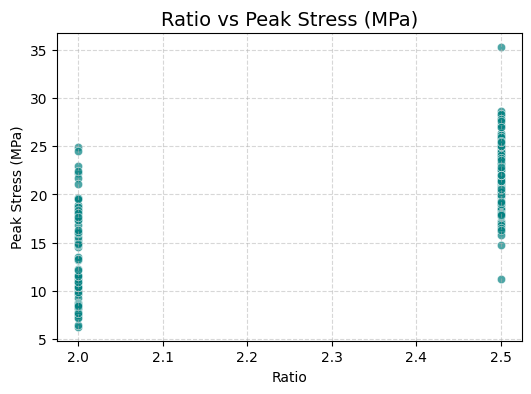

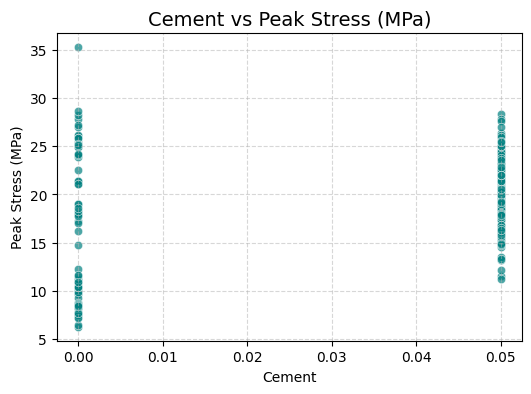

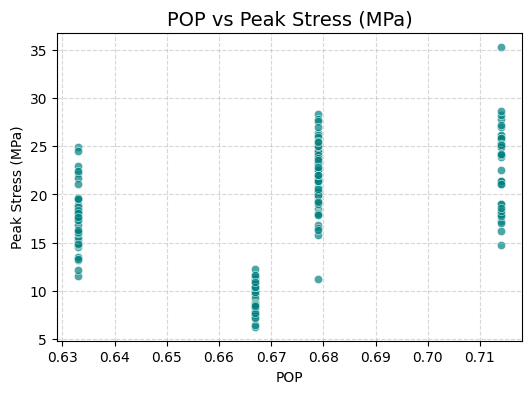

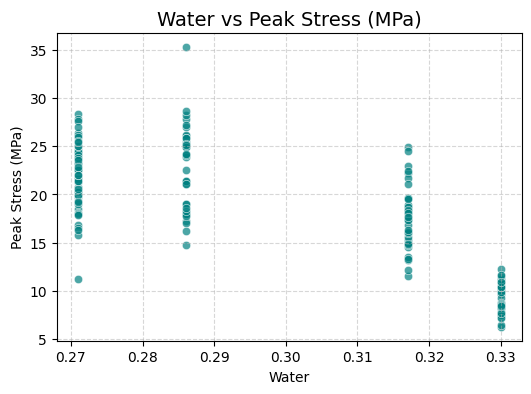

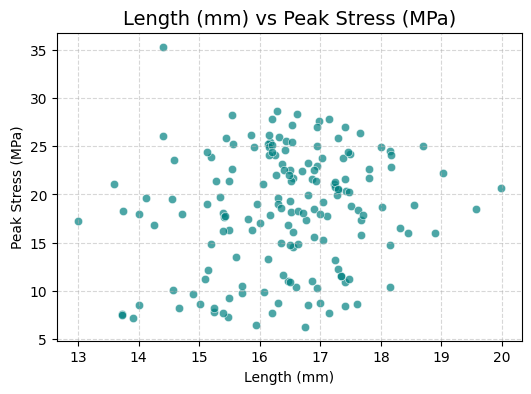

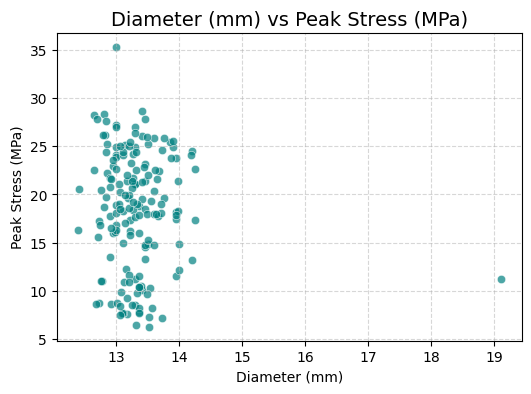

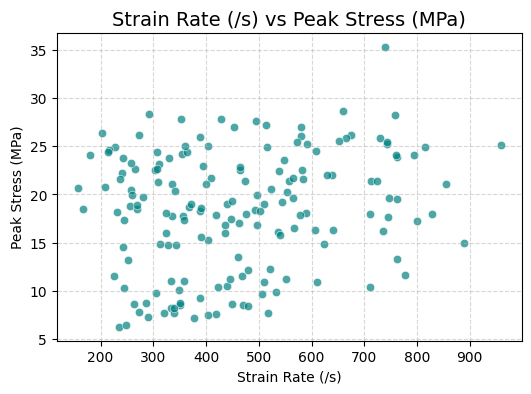

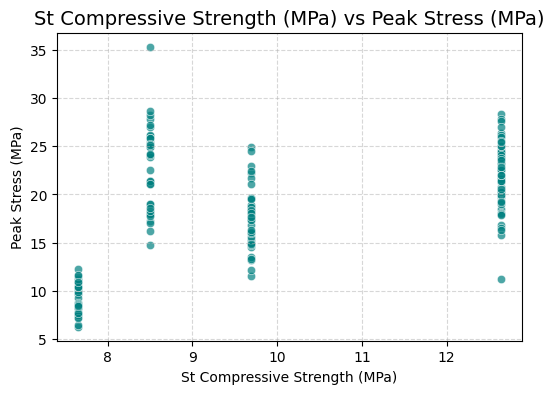

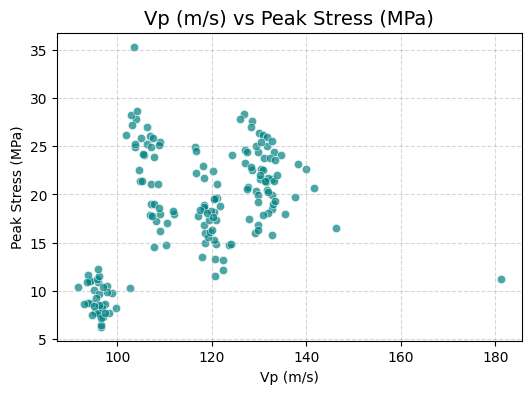

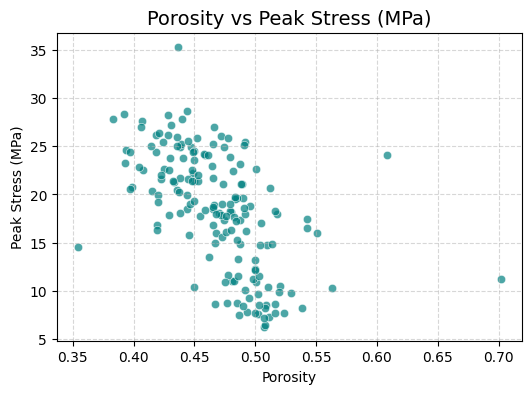

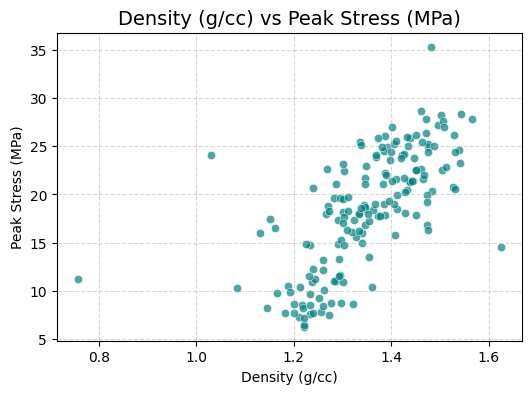

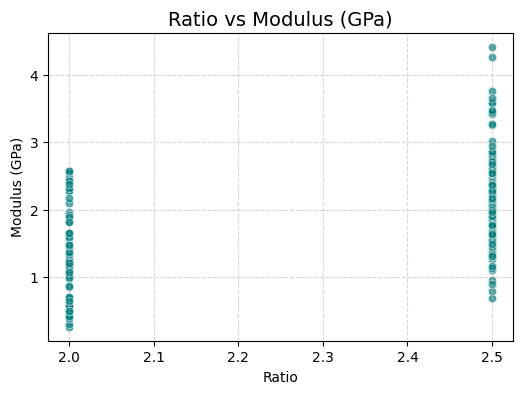

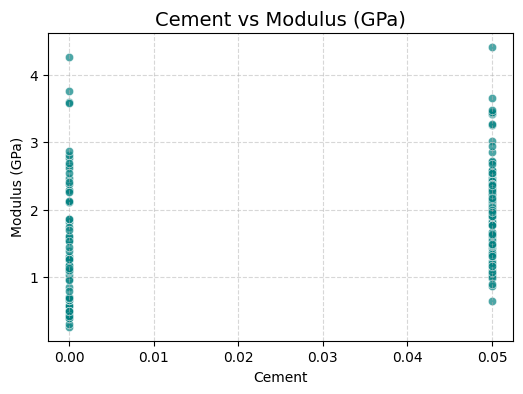

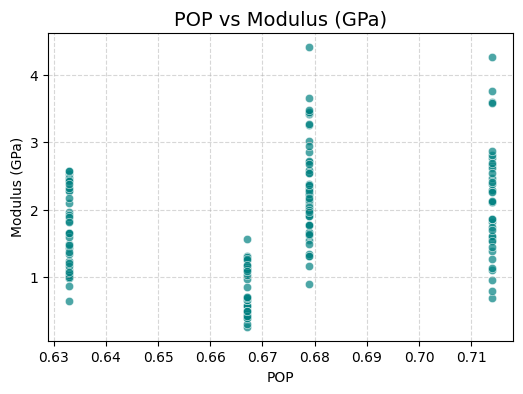

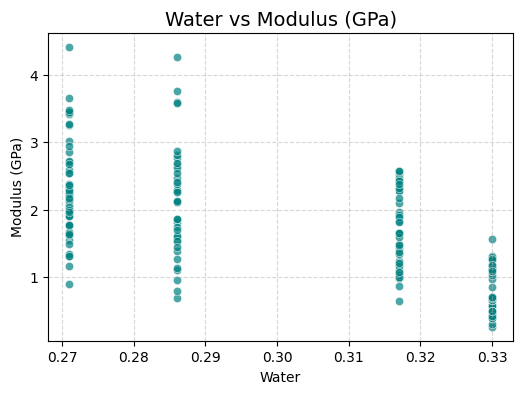

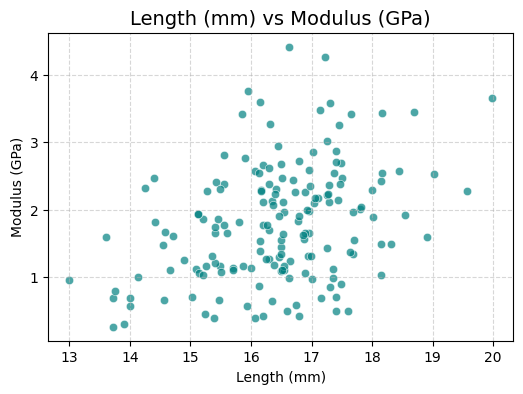

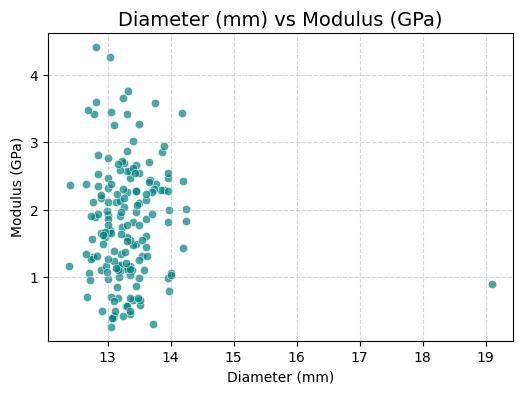

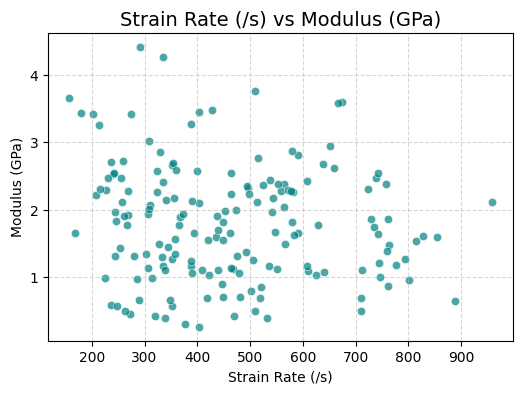

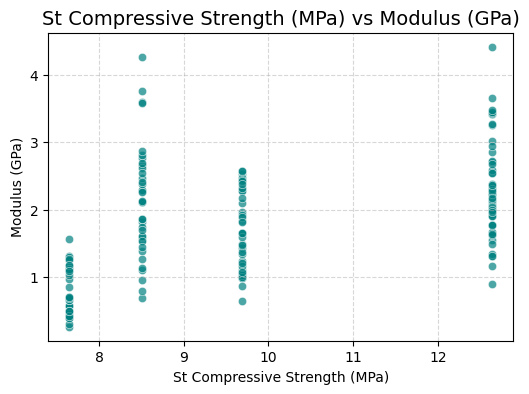

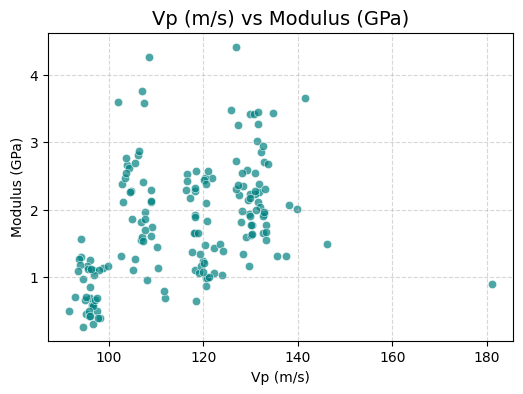

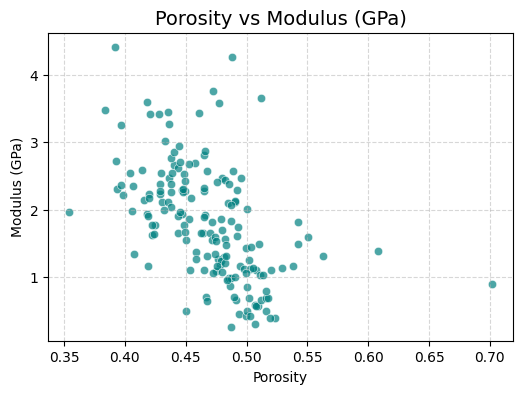

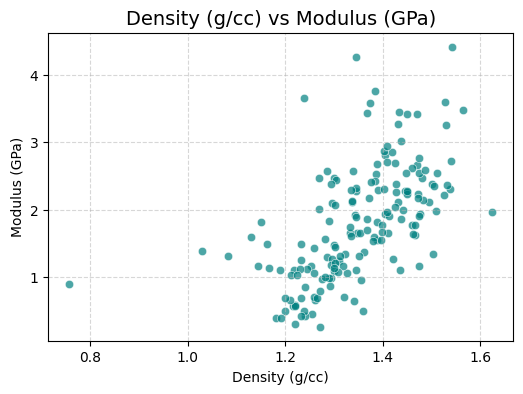

In [ ]:
import seaborn as sns
# Define target variables
targets = ['Peak Stress (MPa)', 'Modulus (GPa)']

# Define features (exclude targets)
features = [col for col in df.columns if col not in targets]

# Loop through targets and plot scatterplots with features
for target in targets:
    for feature in features:
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=df[feature], y=df[target], alpha=0.7, color="teal")
        plt.title(f"{feature} vs {target}", fontsize=14)
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.show()

In [ ]:
# Features and targets
X = df[[ 'Ratio',
    'Cement',
    'POP',
    'Water',
    'Length (mm)',
    'Diameter (mm)',
    'Strain Rate (/s)',
    'St Compressive Strength (MPa)',
    'Vp (m/s)',
    'Porosity',
    'Density (g/cc)']]
y_peak = df['Peak Stress (MPa)']
y_modulus = df['Modulus (GPa)']

# Scale features
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split for both targets
X_train, X_test, y_train_peak, y_test_peak = train_test_split(
    X_scaled, y_peak, test_size=0.2, random_state=42
)
_, _, y_train_mod, y_test_mod = train_test_split(
    X_scaled, y_modulus, test_size=0.2, random_state=42
)

### Outlier Removal using IQR

Outliers can significantly impact model training. The Interquartile Range (IQR) method is a common way to identify and remove them. For each numerical feature, we'll calculate the first quartile (Q1) and third quartile (Q3), and then define the IQR as Q3 - Q1. Any data point falling outside the range `[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]` will be considered an outlier and removed.

# New section

In [ ]:
rf_peak = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_peak.fit(X_train, y_train_peak)

# Predictions
y_pred_peak = rf_peak.predict(X_test)

# Evaluation
r2_peak = r2_score(y_test_peak, y_pred_peak)
rmse_peak = np.sqrt(mean_squared_error(y_test_peak, y_pred_peak))

print("📌 PeakStress Prediction:")
print(f"R² Score: {r2_peak:.4f}")
print(f"RMSE: {rmse_peak:.4f}")

📌 PeakStress Prediction:
R² Score: 0.8526
RMSE: 2.3819


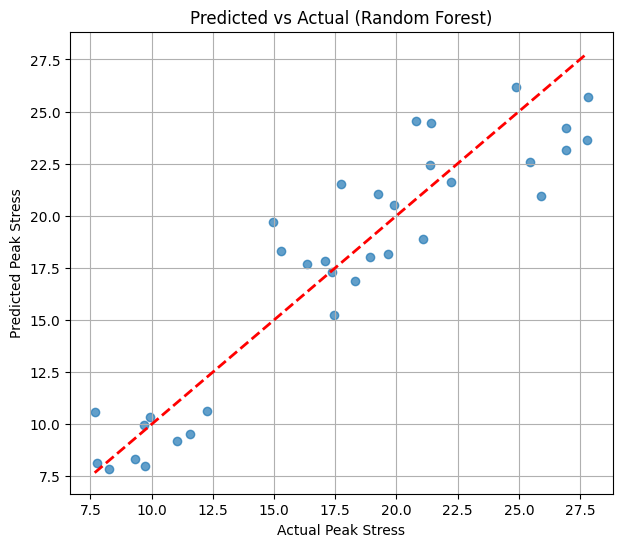

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
plt.scatter(y_test_peak, y_pred_peak, alpha=0.7)
plt.xlabel("Actual Peak Stress")
plt.ylabel("Predicted Peak Stress")
plt.title("Predicted vs Actual (Random Forest)")
plt.plot([y_test_peak.min(), y_test_peak.max()],
         [y_test_peak.min(), y_test_peak.max()],
         'r--', lw=2)  # 45-degree line
plt.grid(True)
plt.show()

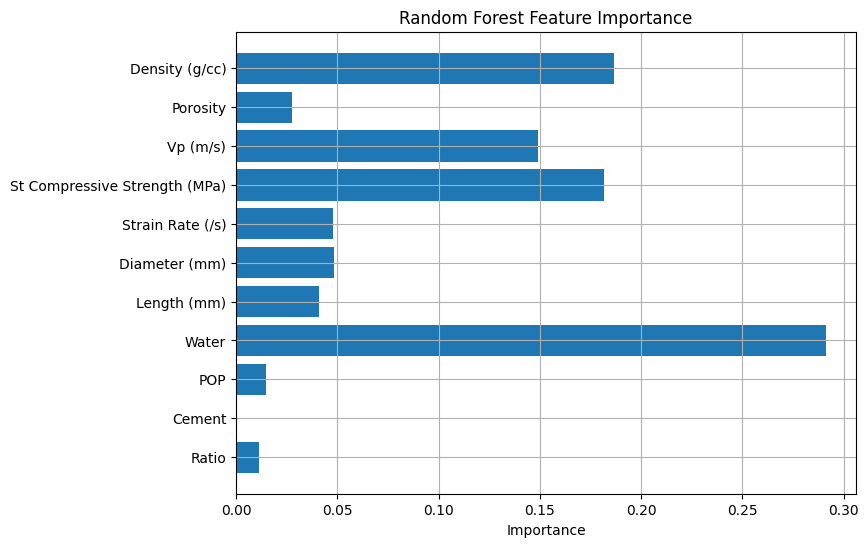

In [ ]:
import numpy as np

feature_importance = rf_peak.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8, 6))
plt.barh(feature_names, feature_importance)
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.grid(True)
plt.show()

📌 Modulus Prediction:
R² Score: 0.4818
RMSE: 0.6578


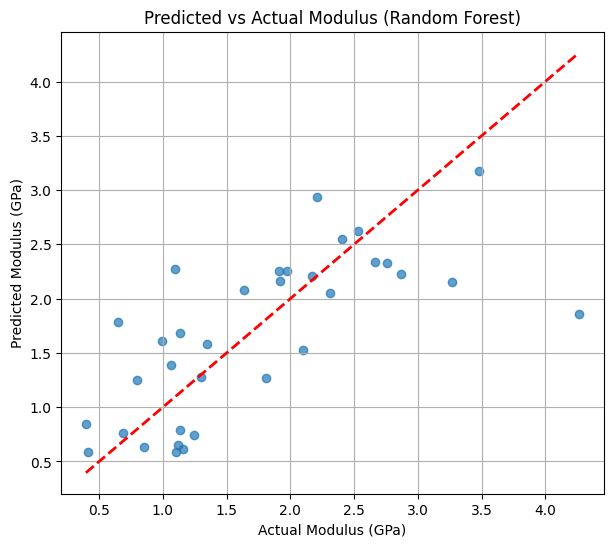

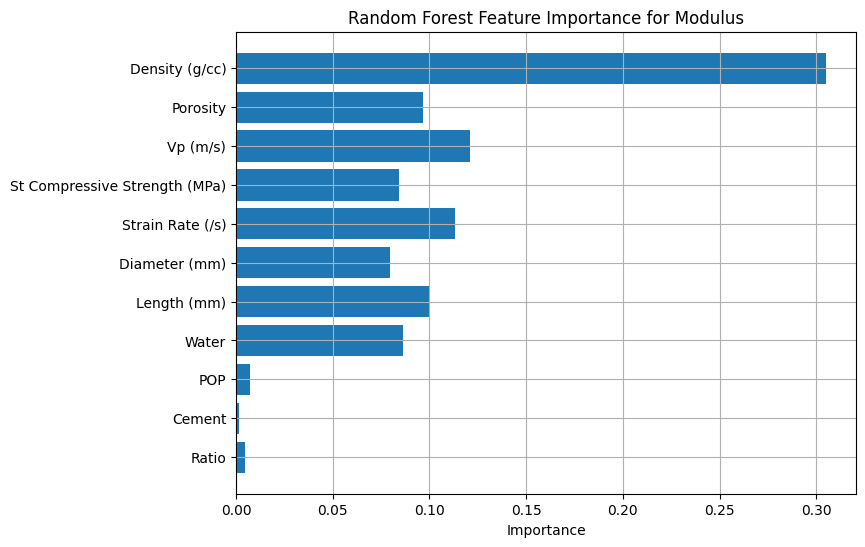

In [ ]:
rf_mod = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_mod.fit(X_train, y_train_mod)

# Predictions
y_pred_mod = rf_mod.predict(X_test)

# Evaluation
r2_mod = r2_score(y_test_mod, y_pred_mod)
rmse_mod = np.sqrt(mean_squared_error(y_test_mod, y_pred_mod))

print("📌 Modulus Prediction:")
print(f"R² Score: {r2_mod:.4f}")
print(f"RMSE: {rmse_mod:.4f}")

plt.figure(figsize=(7, 6))
plt.scatter(y_test_mod, y_pred_mod, alpha=0.7)
plt.xlabel("Actual Modulus (GPa)")
plt.ylabel("Predicted Modulus (GPa)")
plt.title("Predicted vs Actual Modulus (Random Forest)")
plt.plot([y_test_mod.min(), y_test_mod.max()],
         [y_test_mod.min(), y_test_mod.max()],
         'r--', lw=2)  # 45-degree line
plt.grid(True)
plt.show()

feature_importance_mod = rf_mod.feature_importances_
feature_names_mod = features # Changed from feature_cols

plt.figure(figsize=(8, 6))
plt.barh(feature_names_mod, feature_importance_mod)
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance for Modulus")
plt.grid(True)
plt.show()

--- XGBoost Model for Modulus Prediction ---
Training set size: 134
Test set size: 34

Training the XGBoost model for Modulus...
XGBoost Model training complete for Modulus.

--- XGBoost Model Evaluation for Modulus Prediction ---
R² Score: 0.4837
RMSE: 0.6566
MAE: 0.4976


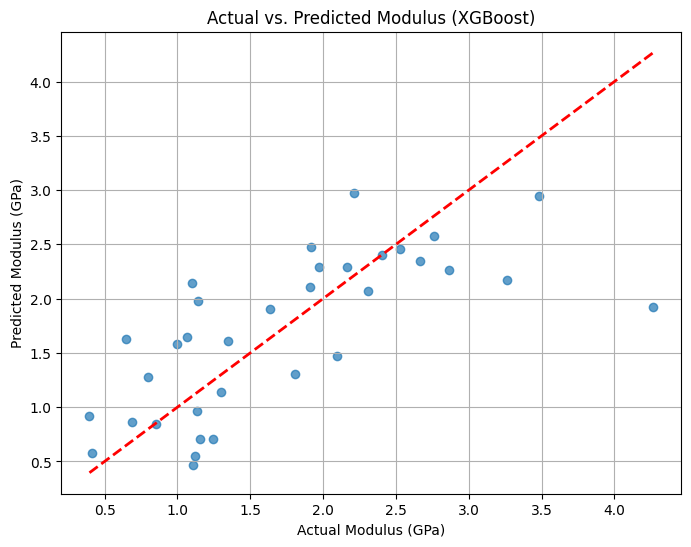

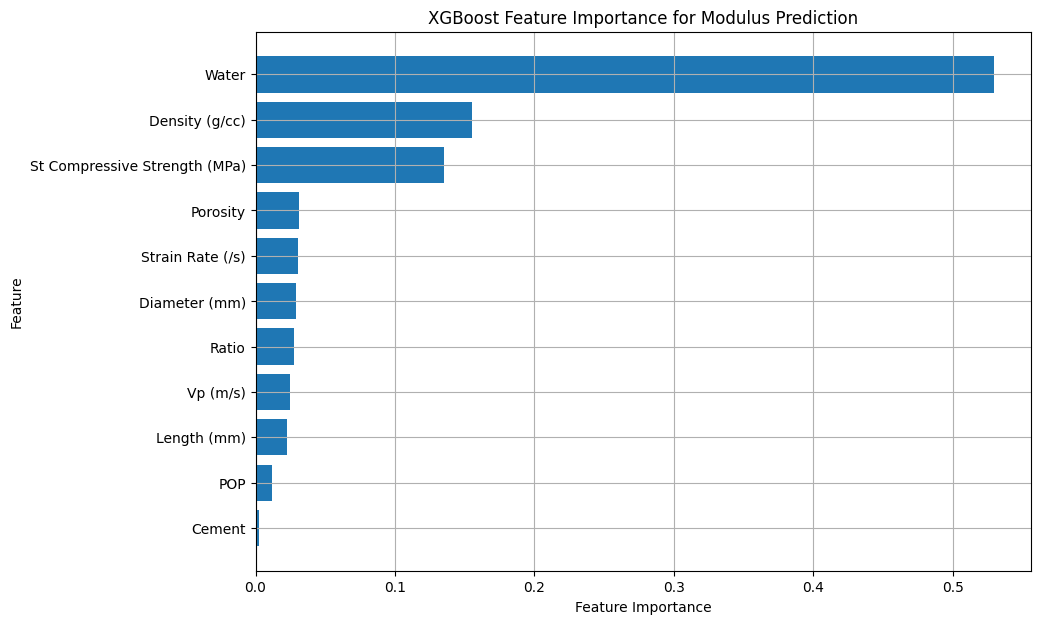

In [ ]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

print("--- XGBoost Model for Modulus Prediction ---")

# X_train, X_test, y_train_mod, y_test_mod are already available from previous cells
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Initialize and train the XGBoost Regressor
model_xgb_mod = xgb.XGBRegressor(
    objective='reg:squarederror', # Objective for regression tasks
    n_estimators=100,             # Number of boosting rounds
    learning_rate=0.1,            # Step size shrinkage to prevent overfitting
    max_depth=5,                  # Maximum depth of a tree
    subsample=0.8,                # Subsample ratio of the training instance
    colsample_bytree=0.8,         # Subsample ratio of columns when constructing each tree
    random_state=42,
    n_jobs=-1                     # Use all available CPU cores
)

print("\nTraining the XGBoost model for Modulus...")
model_xgb_mod.fit(X_train, y_train_mod)
print("XGBoost Model training complete for Modulus.")

# Make predictions on the test set
y_pred_xgb_mod = model_xgb_mod.predict(X_test)

# Evaluate the XGBoost model
r2_xgb_mod = r2_score(y_test_mod, y_pred_xgb_mod)
rmse_xgb_mod = np.sqrt(mean_squared_error(y_test_mod, y_pred_xgb_mod))
mae_xgb_mod = mean_absolute_error(y_test_mod, y_pred_xgb_mod)

print("\n--- XGBoost Model Evaluation for Modulus Prediction ---")
print(f"R\u00b2 Score: {r2_xgb_mod:.4f}")
print(f"RMSE: {rmse_xgb_mod:.4f}")
print(f"MAE: {mae_xgb_mod:.4f}")

# Plotting actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test_mod, y_pred_xgb_mod, alpha=0.7)
plt.plot([y_test_mod.min(), y_test_mod.max()],
         [y_test_mod.min(), y_test_mod.max()],
         'r--', lw=2) # 45-degree line
plt.xlabel("Actual Modulus (GPa)")
plt.ylabel("Predicted Modulus (GPa)")
plt.title("Actual vs. Predicted Modulus (XGBoost)")
plt.grid(True)
plt.show()

# Plotting Feature Importance
feature_importance_xgb_mod = model_xgb_mod.feature_importances_
feature_names_xgb_mod = np.array(features) # Convert to numpy array for advanced indexing

# Sort feature importances for better visualization
sorted_idx = feature_importance_xgb_mod.argsort()[::-1]

plt.figure(figsize=(10, 7))
plt.barh(feature_names_xgb_mod[sorted_idx], feature_importance_xgb_mod[sorted_idx])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance for Modulus Prediction")
plt.gca().invert_yaxis() # Display most important feature at the top
plt.grid(True)
plt.show()

### 5. XGBoost with Smoothed Modulus Data

To address the request to "smothen" the data of tangent modulus, we will apply a Gaussian filter to the `Modulus (GPa)` target variable. This aims to reduce potential noise in the target, allowing the model to learn a smoother underlying relationship. We will then retrain an XGBoost model on this smoothed target.

--- Smoothing Modulus (GPa) Target ---

Original Modulus (GPa) head:


,Modulus (GPa)
0,0.4481
1,0.5650
2,0.4979
3,0.5869
4,0.5716



Smoothed Modulus (GPa) head (sigma=2):


,Modulus (GPa) (Smoothed)
0,0.517406
1,0.538053
2,0.582124
3,0.651033
4,0.736354


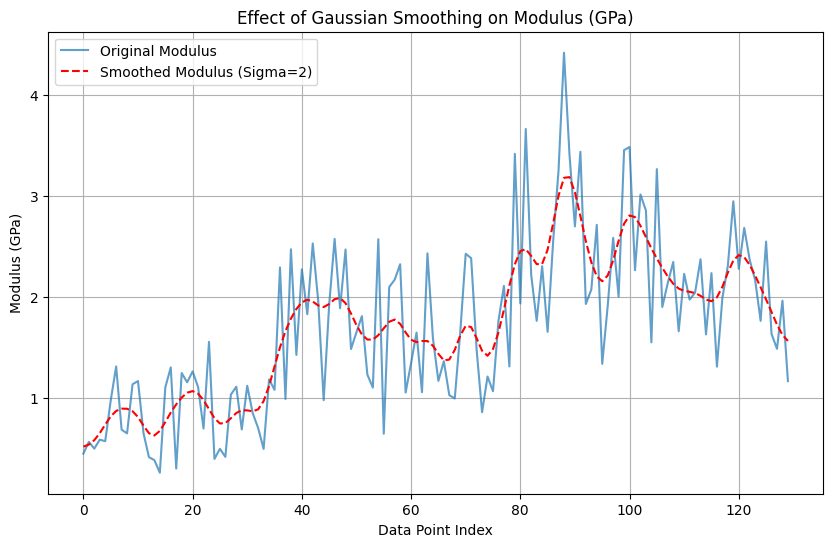

In [ ]:
from scipy.ndimage import gaussian_filter1d

print("--- Smoothing Modulus (GPa) Target ---\n")

# Retrieve the original Modulus (GPa) target from df_filtered
# 'target_mod' is defined as 'Modulus (GPa)' earlier in the notebook
original_y_mod = df_filtered[target_mod]

# Apply Gaussian filter for smoothing. Sigma controls the amount of smoothing.
# A larger sigma means more smoothing.
# We'll use a sigma of 2 as a starting point, which can be adjusted.
sigma_smoothing = 2 # This parameter can be tuned
y_mod_smoothed = gaussian_filter1d(original_y_mod.values, sigma=sigma_smoothing)

# Convert the smoothed array back to a Pandas Series
y_mod_smoothed = pd.Series(y_mod_smoothed, index=original_y_mod.index, name=target_mod + ' (Smoothed)')

print("Original Modulus (GPa) head:")
display(original_y_mod.head())

print("\nSmoothed Modulus (GPa) head (sigma={}):".format(sigma_smoothing))
display(y_mod_smoothed.head())

# Visualize the effect of smoothing
plt.figure(figsize=(10, 6))
plt.plot(original_y_mod.values, label='Original Modulus', alpha=0.7)
plt.plot(y_mod_smoothed.values, label=f'Smoothed Modulus (Sigma={sigma_smoothing})', color='red', linestyle='--')
plt.title('Effect of Gaussian Smoothing on Modulus (GPa)')
plt.xlabel('Data Point Index')
plt.ylabel('Modulus (GPa)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

print("--- Preparing Data for XGBoost with Smoothed Modulus ---\n")

# Re-define X using the original features from df_filtered
# 'feature_cols' is defined earlier in the notebook
# The global 'feature_cols' was overwritten by a later cell.
# Use the 'features' variable which holds the correct list of names.
X_smoothed_target = df_filtered[features] # Use the 'features' variable for correct columns

# Scale features using RobustScaler
scaler_smoothed = RobustScaler()
X_scaled_smoothed = scaler_smoothed.fit_transform(X_smoothed_target)

# Split data into training and testing sets using the smoothed target
X_train_smoothed, X_test_smoothed, y_train_mod_smoothed, y_test_mod_smoothed = train_test_split(
    X_scaled_smoothed, y_mod_smoothed, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training set size (smoothed target): {X_train_smoothed.shape[0]}")
print(f"Test set size (smoothed target): {X_test_smoothed.shape[0]}")

--- Preparing Data for XGBoost with Smoothed Modulus ---

Training set size (smoothed target): 104
Test set size (smoothed target): 26


--- XGBoost Model for Smoothed Modulus Prediction ---

Training the XGBoost model for Smoothed Modulus...
XGBoost Model training complete for Smoothed Modulus.

--- XGBoost Model Evaluation for Smoothed Modulus Prediction ---
R² Score (Smoothed Target): 0.9152
RMSE (Smoothed Target): 0.1901
MAE (Smoothed Target): 0.1440


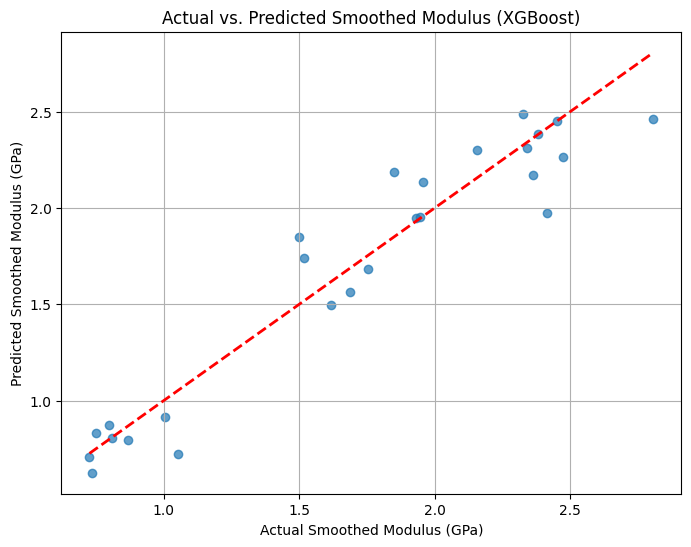

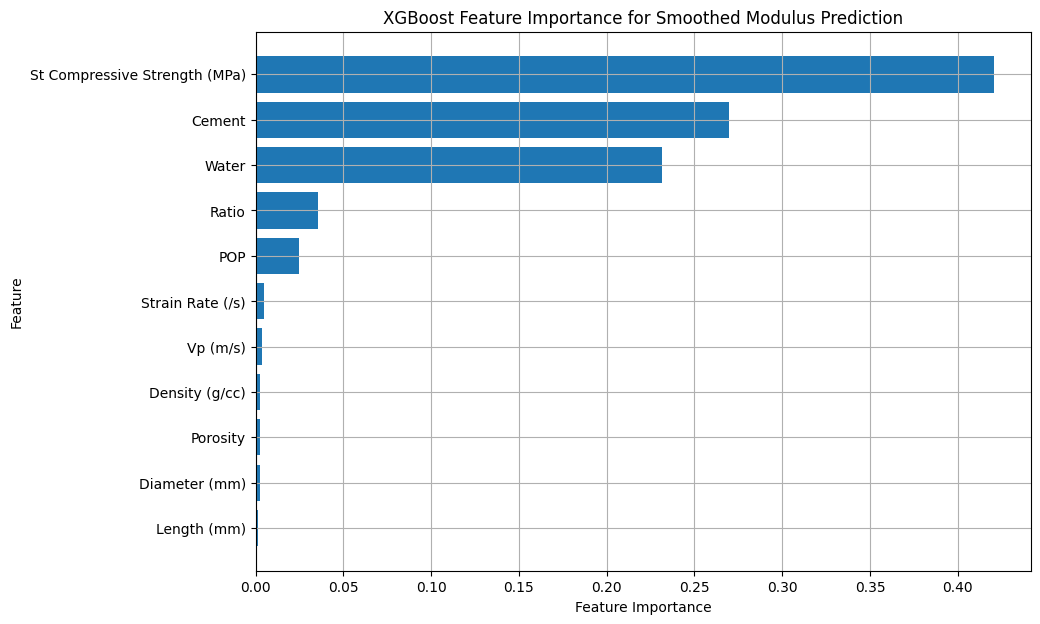

In [ ]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

print("--- XGBoost Model for Smoothed Modulus Prediction ---")

# Initialize and train the XGBoost Regressor
model_xgb_mod_smoothed = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

print("\nTraining the XGBoost model for Smoothed Modulus...")
model_xgb_mod_smoothed.fit(X_train_smoothed, y_train_mod_smoothed)
print("XGBoost Model training complete for Smoothed Modulus.")

# Make predictions on the test set
y_pred_xgb_mod_smoothed = model_xgb_mod_smoothed.predict(X_test_smoothed)

# Evaluate the XGBoost model
r2_xgb_mod_smoothed = r2_score(y_test_mod_smoothed, y_pred_xgb_mod_smoothed)
rmse_xgb_mod_smoothed = np.sqrt(mean_squared_error(y_test_mod_smoothed, y_pred_xgb_mod_smoothed))
mae_xgb_mod_smoothed = mean_absolute_error(y_test_mod_smoothed, y_pred_xgb_mod_smoothed)

print("\n--- XGBoost Model Evaluation for Smoothed Modulus Prediction ---")
print(f"R\u00b2 Score (Smoothed Target): {r2_xgb_mod_smoothed:.4f}")
print(f"RMSE (Smoothed Target): {rmse_xgb_mod_smoothed:.4f}")
print(f"MAE (Smoothed Target): {mae_xgb_mod_smoothed:.4f}")

# Plotting actual vs. predicted values for smoothed target
plt.figure(figsize=(8, 6))
plt.scatter(y_test_mod_smoothed, y_pred_xgb_mod_smoothed, alpha=0.7)
plt.plot([y_test_mod_smoothed.min(), y_test_mod_smoothed.max()],
         [y_test_mod_smoothed.min(), y_test_mod_smoothed.max()],
         'r--', lw=2) # 45-degree line
plt.xlabel("Actual Smoothed Modulus (GPa)")
plt.ylabel("Predicted Smoothed Modulus (GPa)")
plt.title("Actual vs. Predicted Smoothed Modulus (XGBoost)")
plt.grid(True)
plt.show()

# Plotting Feature Importance for smoothed target
feature_importance_xgb_mod_smoothed = model_xgb_mod_smoothed.feature_importances_
feature_names_xgb_mod_smoothed = np.array(features) # Use 'features' for names

sorted_idx_smoothed = feature_importance_xgb_mod_smoothed.argsort()[::-1]

plt.figure(figsize=(10, 7))
plt.barh(feature_names_xgb_mod_smoothed[sorted_idx_smoothed], feature_importance_xgb_mod_smoothed[sorted_idx_smoothed])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance for Smoothed Modulus Prediction")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

here ends peak stress prediction and modulus prediction

prediction of mean fragment size


we can very clearly spot the outlier here

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import pandas as pd

# Load the Excel file, using the second row (index 1) as the header
df_final = pd.read_excel('/content/drive/MyDrive/BTP data with std deviation .xlsx', header=1)

# After setting header=1, it's common for an empty or NaN row to appear as the first data row.
# This line removes that row and resets the index.
df_final = df_final.iloc[1:].reset_index(drop=True)

# Ensure columns are numeric where appropriate, as they might be strings after initial load
df_final = df_final.apply(pd.to_numeric, errors='ignore')

display(df_final.head())

/tmp/ipykernel_903/3770198388.py:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_final = df_final.apply(pd.to_numeric, errors='ignore')


,Ratio,Cement,POP,Water,Length (mm),Diameter (mm),Strain Rate (/s),Dynamic Strength (MPa),St Compressive Strength (MPa),Vp (m/s),Porosity,Density (g/cc),Dynamic Modulus (GPa),Sample No,Shape (k),Scale (λ),Mean (mm),Std (mm)
0,2.0,0.0,0.667,0.33,15.24,13.35,272.057,7.7818,7.649662,95.274226,0.493559,1.254905,0.4481,1.0,0.844226,4.658120,5.089609,6.056838
1,2.0,0.0,0.667,0.33,14.00,13.29,351.444,8.5839,7.649662,96.777616,0.509172,1.216220,0.5650,2.0,0.780000,4.353239,5.025008,6.510719
2,2.0,0.0,0.667,0.33,17.61,12.91,263.246,8.6168,7.649662,97.450533,0.515927,1.199481,0.4979,3.0,0.462270,6.592113,15.406803,38.571061
3,2.0,0.0,0.667,0.33,16.74,13.52,235.840,6.30154,7.649662,96.577561,0.507136,1.221264,0.5869,4.0,0.896619,5.824606,6.141236,6.862048
4,2.0,0.0,0.667,0.33,15.94,13.31,248.412,6.5273,7.649662,96.623816,0.507608,1.220095,0.5716,5.0,0.786500,4.872337,5.589319,7.176652


print("Highest value for each numeric column in df_final:")
for column in df_final.select_dtypes(include=['number']).columns:
    highest_value = df_final[column].max()
    print(f"{column}: {highest_value}")

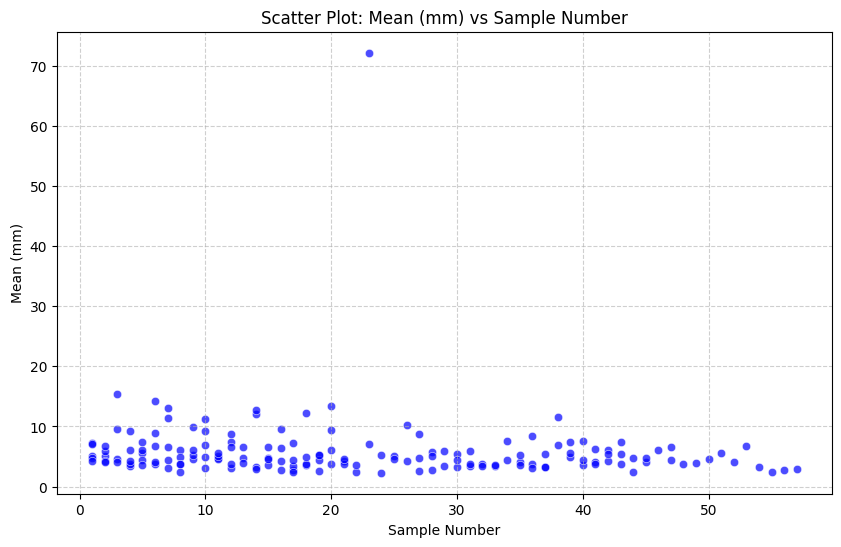

In [12]:






df_final_cleaned = df_final.copy() # Initialize df_final_cleaned from df_final

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_final_cleaned['Sample No'], y=df_final_cleaned['Mean (mm)'], alpha=0.7, color='blue')
plt.title('Scatter Plot: Mean (mm) vs Sample Number')
plt.xlabel('Sample Number')
plt.ylabel('Mean (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [13]:
row_with_highest_mean = df_final_cleaned.loc[df_final_cleaned['Mean (mm)'].idxmax()]
print(row_with_highest_mean)

Ratio                                   2.5
Cement                                 0.05
POP                                   0.679
Water                                 0.271
Length (mm)                           16.95
Diameter (mm)                          13.2
Strain Rate (/s)                     359.71
Dynamic Strength (MPa)              24.9843
St Compressive Strength (MPa)     12.637804
Vp (m/s)                         129.246489
Porosity                           0.414259
Density (g/cc)                     1.486914
Dynamic Modulus (GPa)                2.5842
Sample No                              23.0
Shape (k)                          0.739667
Scale (λ)                         59.899795
Mean (mm)                         72.151398
Std (mm)                          99.131676
Name: 137, dtype: object


In [14]:
index_to_remove = df_final_cleaned['Mean (mm)'].idxmax()
df_final_cleaned = df_final_cleaned.drop(index=index_to_remove).reset_index(drop=True)

print(f"Row with index {index_to_remove} (highest 'Mean (mm)') has been removed.")
print("New DataFrame head:")
display(df_final_cleaned.head())
print("New DataFrame shape:", df_final_cleaned.shape)

Row with index 137 (highest 'Mean (mm)') has been removed.
New DataFrame head:


,Ratio,Cement,POP,Water,Length (mm),Diameter (mm),Strain Rate (/s),Dynamic Strength (MPa),St Compressive Strength (MPa),Vp (m/s),Porosity,Density (g/cc),Dynamic Modulus (GPa),Sample No,Shape (k),Scale (λ),Mean (mm),Std (mm)
0,2.0,0.0,0.667,0.33,15.24,13.35,272.057,7.7818,7.649662,95.274226,0.493559,1.254905,0.4481,1.0,0.844226,4.658120,5.089609,6.056838
1,2.0,0.0,0.667,0.33,14.00,13.29,351.444,8.5839,7.649662,96.777616,0.509172,1.216220,0.5650,2.0,0.780000,4.353239,5.025008,6.510719
2,2.0,0.0,0.667,0.33,17.61,12.91,263.246,8.6168,7.649662,97.450533,0.515927,1.199481,0.4979,3.0,0.462270,6.592113,15.406803,38.571061
3,2.0,0.0,0.667,0.33,16.74,13.52,235.840,6.30154,7.649662,96.577561,0.507136,1.221264,0.5869,4.0,0.896619,5.824606,6.141236,6.862048
4,2.0,0.0,0.667,0.33,15.94,13.31,248.412,6.5273,7.649662,96.623816,0.507608,1.220095,0.5716,5.0,0.786500,4.872337,5.589319,7.176652


New DataFrame shape: (170, 18)


In [15]:
print("Highest value for each numeric column in df_final_cleaned:")
for column in df_final_cleaned.select_dtypes(include=['number']).columns:
    highest_value = df_final_cleaned[column].max()
    print(f"{column}: {highest_value}")

Highest value for each numeric column in df_final_cleaned:
Ratio: 2.5
Cement: 0.05
POP: 0.714
Water: 0.33
Length (mm): 19.98
Diameter (mm): 19.1
Strain Rate (/s): 958.738
St Compressive Strength (MPa): 12.6378036
Vp (m/s): 181.1242022
Porosity: 0.701743362
Density (g/cc): 1.624541891
Dynamic Modulus (GPa): 4.4171
Sample No: 57.0
Shape (k): 1.582463034
Scale (λ): 13.79503821
Mean (mm): 15.40680292
Std (mm): 38.57106132


### 1. Define Features and Target for 'mean (mm)' Prediction (using `df_final_cleaned`)

In [16]:
# Define the target variable
target_column = 'Mean (mm)'

# Define the features by excluding the target and 'std (mm)'
# Assuming df_final_cleaned is the DataFrame loaded in the previous step
# First, identify all columns that are numeric and not the target or 'std (mm)'
all_numeric_cols = df_final_cleaned.select_dtypes(include=['number']).columns

features_to_exclude = [target_column, 'Std (mm)'] # Ensure 'std (mm)' is explicitly excluded

feature_cols_cleaned = [col for col in all_numeric_cols if col not in features_to_exclude]

X_cleaned_data = df_final_cleaned[feature_cols_cleaned]
y_cleaned_data = df_final_cleaned[target_column]

print(f"Target column: {target_column}")
print(f"Number of features: {len(feature_cols_cleaned)}")
print("First 5 feature rows:")
display(X_cleaned_data.head())

Target column: Mean (mm)
Number of features: 15
First 5 feature rows:


,Ratio,Cement,POP,Water,Length (mm),Diameter (mm),Strain Rate (/s),St Compressive Strength (MPa),Vp (m/s),Porosity,Density (g/cc),Dynamic Modulus (GPa),Sample No,Shape (k),Scale (λ)
0,2.0,0.0,0.667,0.33,15.24,13.35,272.057,7.649662,95.274226,0.493559,1.254905,0.4481,1.0,0.844226,4.658120
1,2.0,0.0,0.667,0.33,14.00,13.29,351.444,7.649662,96.777616,0.509172,1.216220,0.5650,2.0,0.780000,4.353239
2,2.0,0.0,0.667,0.33,17.61,12.91,263.246,7.649662,97.450533,0.515927,1.199481,0.4979,3.0,0.462270,6.592113
3,2.0,0.0,0.667,0.33,16.74,13.52,235.840,7.649662,96.577561,0.507136,1.221264,0.5869,4.0,0.896619,5.824606
4,2.0,0.0,0.667,0.33,15.94,13.31,248.412,7.649662,96.623816,0.507608,1.220095,0.5716,5.0,0.786500,4.872337


### 2. GRNN Model for 'Mean (mm)' Prediction (using `df_final_cleaned`)

--- GRNN Model for 'Mean (mm)' Prediction (cleaned data) ---
Training set size: 131
Test set size: 33

Searching for the optimal sigma for Mean (mm) with GRNN (cleaned data)...
Optimal sigma found for GRNN (cleaned data): 0.50

Training the final GRNN model (cleaned data)...
GRNN Model training complete (cleaned data).

--- GRNN Model Evaluation for 'Mean (mm)' Prediction (cleaned data) ---
R² Score: 0.5975
RMSE: 1.4666
MAE: 0.8477


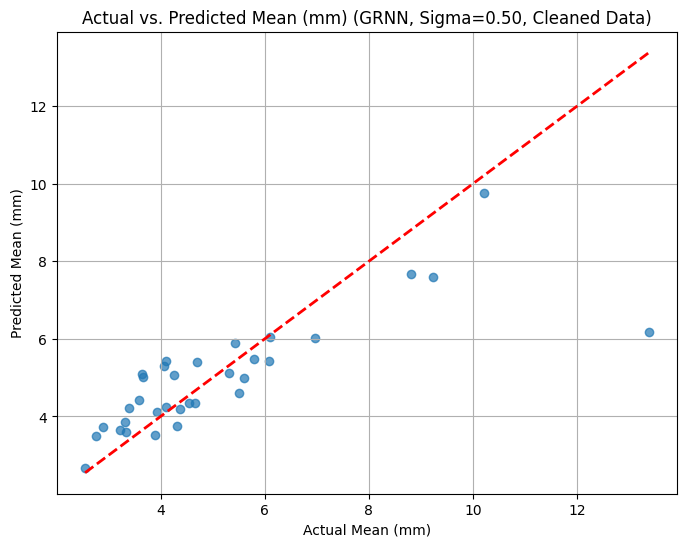

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define the GRNN class as it was not defined previously
class GRNN:
    def __init__(self, sigma=0.1):
        self.sigma = sigma
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        self.X_train = X_train
        # Flatten y_train to ensure it's a 1D array of scalars
        self.y_train = y_train.flatten()

    def predict(self, X_test):
        y_pred = []
        for x_test_point in X_test:
            numerator = 0
            denominator = 0
            for i in range(len(self.X_train)):
                x_train_point = self.X_train[i]
                y_train_point = self.y_train[i] # Now y_train_point is a scalar

                # Euclidean distance
                distance = np.linalg.norm(x_test_point - x_train_point)

                # Gaussian kernel function
                kernel_output = np.exp(-(distance**2) / (2 * self.sigma**2))

                numerator += y_train_point * kernel_output
                denominator += kernel_output

            if denominator == 0:
                # Handle cases where denominator is zero (e.g., no close training points)
                y_pred.append(np.mean(self.y_train)) # Appends a scalar
            else:
                y_pred.append(numerator / denominator) # Appends a scalar
        return np.array(y_pred)


print("--- GRNN Model for 'Mean (mm)' Prediction (cleaned data) ---")

# Combine X and y to easily drop rows with NaN values in the target
df_combined_grnn_cleaned = pd.DataFrame(X_cleaned_data.copy())
df_combined_grnn_cleaned[target_column] = y_cleaned_data.copy()

# Drop rows where the target column ('Mean (mm)') is NaN (though it should be clean here)
df_combined_grnn_cleaned.dropna(subset=[target_column], inplace=True)

X_cleaned_grnn_new = df_combined_grnn_cleaned[feature_cols_cleaned]
y_cleaned_grnn_new = df_combined_grnn_cleaned[target_column]

# Reshape y_cleaned_grnn_new to be 2D as GRNN's predict method assumes 2D output
y_cleaned_2d_grnn_new = y_cleaned_grnn_new.values.reshape(-1, 1)

# Scale features using StandardScaler for GRNN
scaler_grnn_new = StandardScaler()
X_scaled_grnn_new = scaler_grnn_new.fit_transform(X_cleaned_grnn_new)

# Split data into training and testing sets
X_train_grnn_new, X_test_grnn_new, y_train_2d_grnn_new, y_test_2d_grnn_new = train_test_split(
    X_scaled_grnn_new, y_cleaned_2d_grnn_new, test_size=0.2, random_state=42
)

# Flatten y_train_2d_grnn_new and y_test_2d_grnn_new for metrics later
y_train_grnn_flat_new = y_train_2d_grnn_new.flatten()
y_test_grnn_flat_new = y_test_2d_grnn_new.flatten()

print(f"Training set size: {X_train_grnn_new.shape[0]}")
print(f"Test set size: {X_test_grnn_new.shape[0]}")

# Optimize the Smoothing Parameter (Sigma) for GRNN
print("\nSearching for the optimal sigma for Mean (mm) with GRNN (cleaned data)...")
best_sigma_grnn_new = 0.1
best_mae_grnn_new = float('inf')
sigma_values_grnn_new = np.arange(0.05, 2.0, 0.05)

for sigma_val in sigma_values_grnn_new:
    temp_model_grnn_new = GRNN(sigma=sigma_val)
    temp_model_grnn_new.fit(X_train_grnn_new, y_train_2d_grnn_new) # Pass 2D y_train
    temp_preds_2d_grnn_new = temp_model_grnn_new.predict(X_test_grnn_new) # Predicts 1D output as scalars
    temp_preds_grnn_new = temp_preds_2d_grnn_new.flatten() # Flatten for MAE calculation

    current_mae_grnn_new = mean_absolute_error(y_test_grnn_flat_new, temp_preds_grnn_new)

    if current_mae_grnn_new < best_mae_grnn_new:
        best_mae_grnn_new = current_mae_grnn_new
        best_sigma_grnn_new = sigma_val

print(f"Optimal sigma found for GRNN (cleaned data): {best_sigma_grnn_new:.2f}\n")

# Train Final GRNN Model
print("Training the final GRNN model (cleaned data)...")
grnn_model_final_new = GRNN(sigma=best_sigma_grnn_new)
grnn_model_final_new.fit(X_train_grnn_new, y_train_2d_grnn_new)
print("GRNN Model training complete (cleaned data).")

# Make predictions on the test set
y_pred_2d_grnn_new = grnn_model_final_new.predict(X_test_grnn_new)
y_pred_grnn_new = y_pred_2d_grnn_new.flatten()

# Evaluate the GRNN model
r2_grnn_new = r2_score(y_test_grnn_flat_new, y_pred_grnn_new)
rmse_grnn_new = np.sqrt(mean_squared_error(y_test_grnn_flat_new, y_pred_grnn_new))
mae_grnn_new = mean_absolute_error(y_test_grnn_flat_new, y_pred_grnn_new)

print("\n--- GRNN Model Evaluation for 'Mean (mm)' Prediction (cleaned data) ---")
print(f"R² Score: {r2_grnn_new:.4f}")
print(f"RMSE: {rmse_grnn_new:.4f}")
print(f"MAE: {mae_grnn_new:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test_grnn_flat_new, y_pred_grnn_new, alpha=0.7)
plt.plot([y_test_grnn_flat_new.min(), y_test_grnn_flat_new.max()], [y_test_grnn_flat_new.min(), y_test_grnn_flat_new.max()], 'r--', lw=2) # 45-degree line
plt.xlabel("Actual Mean (mm)")
plt.ylabel("Predicted Mean (mm)")
plt.title(f"Actual vs. Predicted Mean (mm) (GRNN, Sigma={best_sigma_grnn_new:.2f}, Cleaned Data)")
plt.grid(True)
plt.show()

### 3. XGBoost Model for 'Mean (mm)' Prediction (using `df_final_cleaned`)

--- XGBoost Model for 'Mean (mm)' Prediction (cleaned data) ---
Training set size: 131
Test set size: 33

Training the XGBoost model (cleaned data)...
XGBoost Model training complete (cleaned data).

--- XGBoost Model Evaluation for 'Mean (mm)' Prediction (cleaned data) ---
R² Score: 0.9190
RMSE: 0.6578
MAE: 0.4028


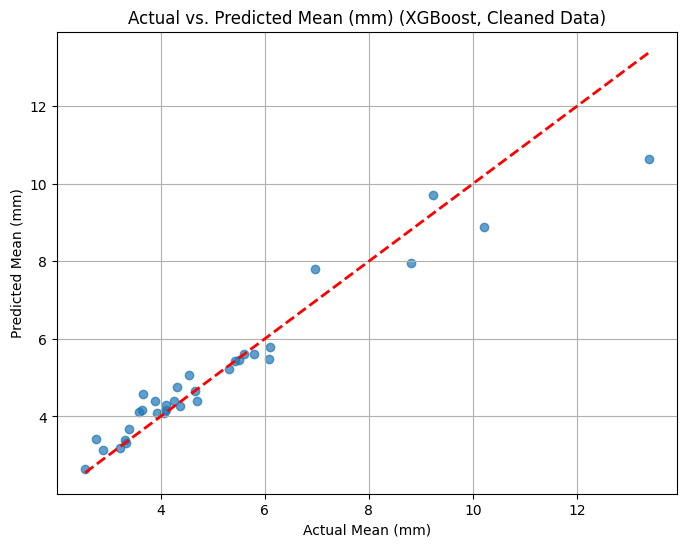

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

print("--- XGBoost Model for 'Mean (mm)' Prediction (cleaned data) ---")

# Re-using cleaned X and y from previous steps for consistency
# X_cleaned_data and y_cleaned_data are already defined

# Scale features using StandardScaler
scaler_xgb_new = StandardScaler()
X_scaled_xgb_new = scaler_xgb_new.fit_transform(X_cleaned_grnn_new) # Use X_cleaned_grnn_new for consistency after GRNN

# Split data into training and testing sets
X_train_xgb_new, X_test_xgb_new, y_train_xgb_new, y_test_xgb_new = train_test_split(
    X_scaled_xgb_new, y_cleaned_grnn_new, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train_xgb_new.shape[0]}")
print(f"Test set size: {X_test_xgb_new.shape[0]}")

# Train XGBoost Model
print("\nTraining the XGBoost model (cleaned data)...")
model_xgb_new = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_xgb_new.fit(X_train_xgb_new, y_train_xgb_new)
print("XGBoost Model training complete (cleaned data).")

# Make predictions on the test set
y_pred_xgb_new = model_xgb_new.predict(X_test_xgb_new)

# Evaluate the XGBoost model
r2_xgb_new = r2_score(y_test_xgb_new, y_pred_xgb_new)
rmse_xgb_new = np.sqrt(mean_squared_error(y_test_xgb_new, y_pred_xgb_new))
mae_xgb_new = mean_absolute_error(y_test_xgb_new, y_pred_xgb_new)

print("\n--- XGBoost Model Evaluation for 'Mean (mm)' Prediction (cleaned data) ---")
print(f"R² Score: {r2_xgb_new:.4f}")
print(f"RMSE: {rmse_xgb_new:.4f}")
print(f"MAE: {mae_xgb_new:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test_xgb_new, y_pred_xgb_new, alpha=0.7)
plt.plot([y_test_xgb_new.min(), y_test_xgb_new.max()], [y_test_xgb_new.min(), y_test_xgb_new.max()], 'r--', lw=2) # 45-degree line
plt.xlabel("Actual Mean (mm)")
plt.ylabel("Predicted Mean (mm)")
plt.title("Actual vs. Predicted Mean (mm) (XGBoost, Cleaned Data)")
plt.grid(True)
plt.show()

### 4. SVR Model for 'Mean (mm)' Prediction (using `df_final_cleaned`)

--- SVR Model for 'Mean (mm)' Prediction (cleaned data) ---
Training set size: 131
Test set size: 33

Training the SVR model (cleaned data)...
SVR Model training complete (cleaned data).

--- SVR Model Evaluation for 'Mean (mm)' Prediction (cleaned data) ---
R² Score: 0.9527
RMSE: 0.5030
MAE: 0.3468


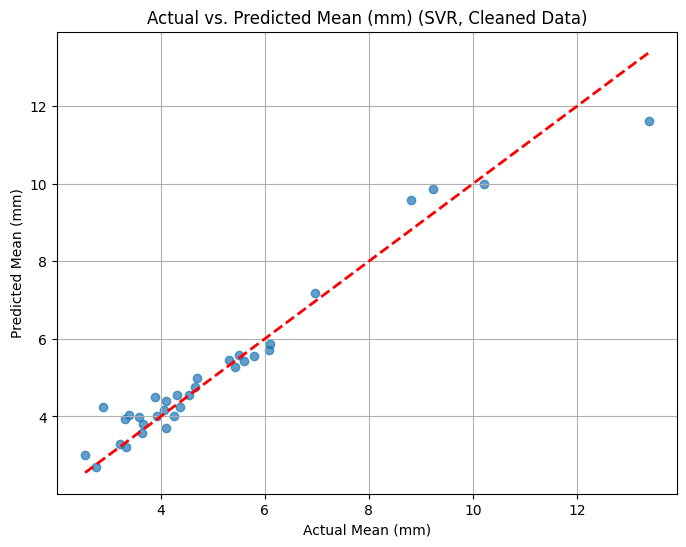

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("--- SVR Model for 'Mean (mm)' Prediction (cleaned data) ---")

# Re-using cleaned X and y from previous steps for consistency
# X_cleaned_grnn_new and y_cleaned_grnn_new are already defined and used in GRNN/XGBoost

# Scale features using StandardScaler
scaler_svr_new = StandardScaler()
X_scaled_svr_new = scaler_svr_new.fit_transform(X_cleaned_grnn_new) # Use X_cleaned_grnn_new for consistency

# Split data into training and testing sets
X_train_svr_new, X_test_svr_new, y_train_svr_new, y_test_svr_new = train_test_split(
    X_scaled_svr_new, y_cleaned_grnn_new, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train_svr_new.shape[0]}")
print(f"Test set size: {X_test_svr_new.shape[0]}")

# Train SVR Model
print("\nTraining the SVR model (cleaned data)...")
# RBF kernel is a common choice for non-linear relationships
# C and gamma are important hyperparameters; typical values are used as a starting point
model_svr_new = SVR(kernel='rbf', C=100, gamma=0.1)

model_svr_new.fit(X_train_svr_new, y_train_svr_new)
print("SVR Model training complete (cleaned data).")

# Make predictions on the test set
y_pred_svr_new = model_svr_new.predict(X_test_svr_new)

# Evaluate the SVR model
r2_svr_new = r2_score(y_test_svr_new, y_pred_svr_new)
rmse_svr_new = np.sqrt(mean_squared_error(y_test_svr_new, y_pred_svr_new))
mae_svr_new = mean_absolute_error(y_test_svr_new, y_pred_svr_new)

print("\n--- SVR Model Evaluation for 'Mean (mm)' Prediction (cleaned data) ---")
print(f"R² Score: {r2_svr_new:.4f}")
print(f"RMSE: {rmse_svr_new:.4f}")
print(f"MAE: {mae_svr_new:.4f}")

# Plotting actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test_svr_new, y_pred_svr_new, alpha=0.7)
plt.plot([y_test_svr_new.min(), y_test_svr_new.max()], [y_test_svr_new.min(), y_test_svr_new.max()], 'r--', lw=2) # 45-degree line
plt.xlabel("Actual Mean (mm)")
plt.ylabel("Predicted Mean (mm)")
plt.title("Actual vs. Predicted Mean (mm) (SVR, Cleaned Data)")
plt.grid(True)
plt.show()

--- Model Performance Summary (on Cleaned Data) ---


,Model,R2 Score,RMSE,MAE
0,GRNN,0.5975,1.4666,0.8477
1,XGBoost,0.9190,0.6578,0.4028
2,SVR,0.9527,0.5030,0.3468


/tmp/ipykernel_903/3937171936.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=model_performance_summary, palette='viridis')
/tmp/ipykernel_903/3937171936.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=model_performance_summary, palette='magma')
/tmp/ipykernel_903/3937171936.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MAE', data=model_performance_summary, palette='cividis')


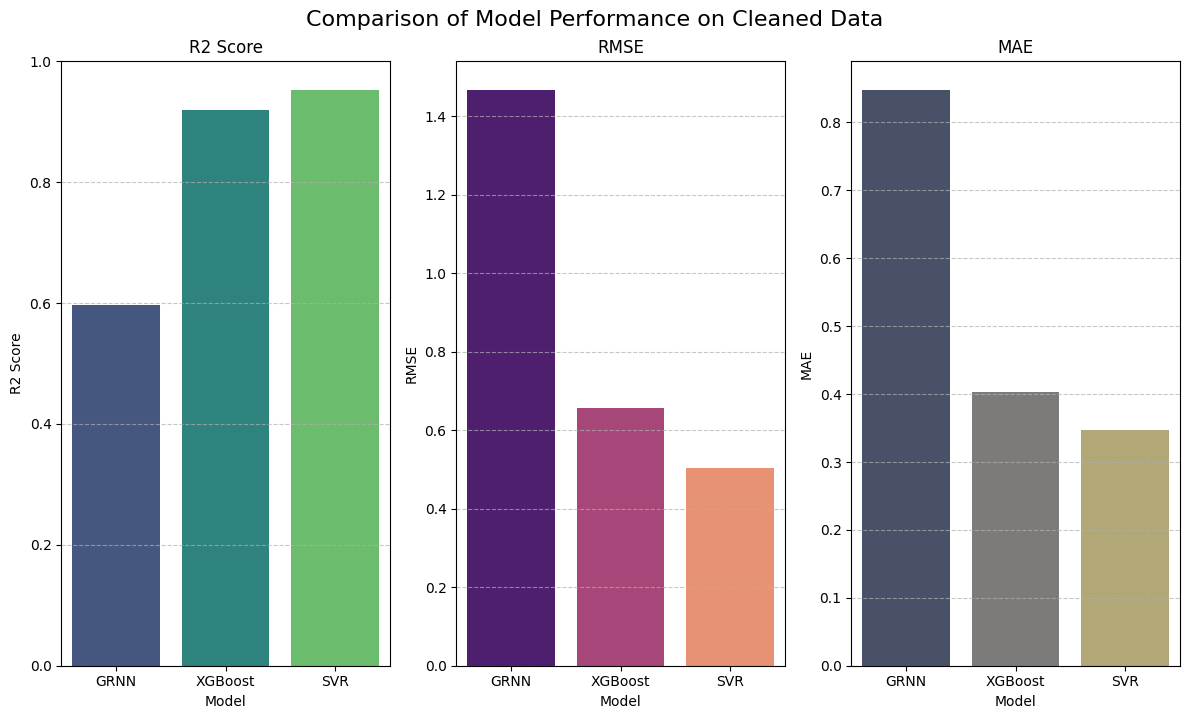

In [23]:
model_performance_summary = pd.DataFrame({
    'Model': ['GRNN', 'XGBoost', 'SVR'],
    'R2 Score': [r2_grnn_new, r2_xgb_new, r2_svr_new],
    'RMSE': [rmse_grnn_new, rmse_xgb_new, rmse_svr_new],
    'MAE': [mae_grnn_new, mae_xgb_new, mae_svr_new]
})

print("--- Model Performance Summary (on Cleaned Data) ---")
display(model_performance_summary.round(4))

plt.figure(figsize=(12, 7))

# R2 Score Plot
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.barplot(x='Model', y='R2 Score', data=model_performance_summary, palette='viridis')
plt.title('R2 Score')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# RMSE Plot
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.barplot(x='Model', y='RMSE', data=model_performance_summary, palette='magma')
plt.title('RMSE')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# MAE Plot
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
sns.barplot(x='Model', y='MAE', data=model_performance_summary, palette='cividis')
plt.title('MAE')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('Comparison of Model Performance on Cleaned Data', y=1.02, fontsize=16)
plt.show()

--- SVR Model for 'Mean (mm)' Prediction (cleaned data) ---
Training set size: 131
Test set size: 33

Training the SVR model (cleaned data)...
SVR Model training complete (cleaned data).

--- SVR Model Evaluation for 'Mean (mm)' Prediction (cleaned data) ---
R² Score: 0.9527
RMSE: 0.5030
MAE: 0.3468


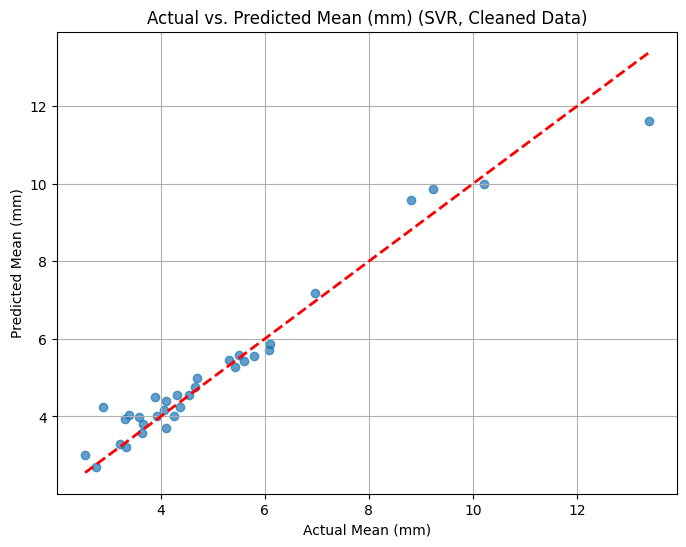

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("--- SVR Model for 'Mean (mm)' Prediction (cleaned data) ---")

# Re-using cleaned X and y from previous steps for consistency
# X_cleaned_data and y_cleaned_data are already defined

# Scale features using StandardScaler
scaler_svr_new = StandardScaler()
X_scaled_svr_new = scaler_svr_new.fit_transform(X_cleaned_grnn_new) # Use X_cleaned_grnn_new for consistency

# Split data into training and testing sets
X_train_svr_new, X_test_svr_new, y_train_svr_new, y_test_svr_new = train_test_split(
    X_scaled_svr_new, y_cleaned_grnn_new, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train_svr_new.shape[0]}")
print(f"Test set size: {X_test_svr_new.shape[0]}")

# Train SVR Model
print("\nTraining the SVR model (cleaned data)...")
model_svr_new = SVR(kernel='rbf', C=100, gamma=0.1) # RBF kernel is a good starting point

model_svr_new.fit(X_train_svr_new, y_train_svr_new)
print("SVR Model training complete (cleaned data).")

# Make predictions on the test set
y_pred_svr_new = model_svr_new.predict(X_test_svr_new)

# Evaluate the SVR model
r2_svr_new = r2_score(y_test_svr_new, y_pred_svr_new)
rmse_svr_new = np.sqrt(mean_squared_error(y_test_svr_new, y_pred_svr_new))
mae_svr_new = mean_absolute_error(y_test_svr_new, y_pred_svr_new)

print("\n--- SVR Model Evaluation for 'Mean (mm)' Prediction (cleaned data) ---")
print(f"R² Score: {r2_svr_new:.4f}")
print(f"RMSE: {rmse_svr_new:.4f}")
print(f"MAE: {mae_svr_new:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test_svr_new, y_pred_svr_new, alpha=0.7)
plt.plot([y_test_svr_new.min(), y_test_svr_new.max()], [y_test_svr_new.min(), y_test_svr_new.max()], 'r--', lw=2) # 45-degree line
plt.xlabel("Actual Mean (mm)")
plt.ylabel("Predicted Mean (mm)")
plt.title("Actual vs. Predicted Mean (mm) (SVR, Cleaned Data)")
plt.grid(True)
plt.show()